# 02 - Model Comparison v2
## Perbandingan Algoritma ML dengan Data 12 Bulan + StandardScaler

**Perbedaan dengan v1:**
- 365 hari data (vs 91 hari)
- StandardScaler diterapkan pada semua fitur
- 12 fitur (termasuk is_ramadan, is_holiday, month)
- TimeSeriesSplit cross-validation (vs simple 80/20 split)

**Referensi:**
- Bergmeir, C. & Benítez, J.M. (2012). *On the use of cross-validation for time series predictor evaluation.* Information Sciences.
- Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed.

In [1]:
# Cell 1: Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
print('Libraries loaded!')

Libraries loaded!


In [2]:
# Cell 2: Prepare Daily Data + Features
df_tx = pd.read_csv('data_v2/transactions.csv')
df_tx['date'] = pd.to_datetime(df_tx['date'])

daily = df_tx.groupby('date').agg(
    revenue=('total', 'sum'),
    tx_count=('transaction_code', 'count'),
    day_of_week=('day_of_week', 'first'),
    is_weekend=('is_weekend', 'first'),
    is_payday=('is_payday', 'first'),
    event=('event', 'first')
).reset_index()

print(f'Total hari data: {len(daily)}')
print(f'Revenue range: Rp {daily["revenue"].min():,.0f} - Rp {daily["revenue"].max():,.0f}')
daily.head()

Total hari data: 365
Revenue range: Rp 116,000 - Rp 2,310,650


,date,revenue,tx_count,day_of_week,is_weekend,is_payday,event
0,2025-07-01,806100,27,1,0,1,normal
1,2025-07-02,1246900,30,2,0,1,normal
2,2025-07-03,1156250,27,3,0,1,normal
3,2025-07-04,707400,21,4,0,1,normal
4,2025-07-05,1878650,36,5,1,1,normal


In [3]:
# Cell 3: Feature Engineering (12 fitur)
daily['rolling_7d_avg'] = daily['revenue'].rolling(7).mean()
daily['rolling_3d_avg'] = daily['revenue'].rolling(3).mean()
daily['rolling_14d_avg'] = daily['revenue'].rolling(14).mean()
daily['lag_1'] = daily['revenue'].shift(1)
daily['lag_7'] = daily['revenue'].shift(7)
daily['day_sin'] = np.sin(2 * np.pi * daily['day_of_week'] / 7)
daily['day_cos'] = np.cos(2 * np.pi * daily['day_of_week'] / 7)
daily['month'] = daily['date'].dt.month
daily['is_ramadan'] = daily['event'].apply(lambda x: 1 if x in ['ramadan', 'pre_lebaran'] else 0)
daily['is_holiday'] = daily['event'].apply(lambda x: 1 if x == 'holiday' else 0)

# Drop NaN dari rolling/lag
daily_clean = daily.dropna().reset_index(drop=True)

print(f'Data setelah feature engineering: {len(daily_clean)} hari')
print(f'\nFitur yang tersedia ({len([c for c in daily_clean.columns if c not in ["date","revenue","event","tx_count"]])}):') 
for c in daily_clean.columns:
    if c not in ['date', 'revenue', 'event', 'tx_count']:
        print(f'  - {c}')

Data setelah feature engineering: 352 hari

Fitur yang tersedia (13):
  - day_of_week
  - is_weekend
  - is_payday
  - rolling_7d_avg
  - rolling_3d_avg
  - rolling_14d_avg
  - lag_1
  - lag_7
  - day_sin
  - day_cos
  - month
  - is_ramadan
  - is_holiday


In [4]:
# Cell 4: Feature Set Experiment + StandardScaler
print('='*70)
print('EKSPERIMEN FEATURE SET (dengan StandardScaler)')
print('='*70)

feature_sets = {
    'Basic (2 fitur)': ['day_of_week', 'is_weekend'],
    'Medium (4 fitur - v1)': ['day_of_week', 'is_weekend', 'is_payday', 'rolling_7d_avg'],
    'Full (8 fitur)': ['day_of_week', 'is_weekend', 'is_payday', 'rolling_7d_avg',
                       'rolling_3d_avg', 'lag_1', 'day_sin', 'day_cos'],
    'Extended (12 fitur - v2)': ['day_of_week', 'is_weekend', 'is_payday', 'rolling_7d_avg',
                                 'rolling_3d_avg', 'lag_1', 'lag_7', 'day_sin', 'day_cos',
                                 'is_ramadan', 'is_holiday', 'month']
}

# Split: 80% train, 20% test (tetap kronologis)
split_idx = int(len(daily_clean) * 0.8)
y = daily_clean['revenue'].values

results = []
for name, features in feature_sets.items():
    X = daily_clean[features].values
    
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # StandardScaler: fit on train, transform both
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    model = Ridge(alpha=1.0)
    model.fit(X_train_s, y_train)
    
    r2_train = r2_score(y_train, model.predict(X_train_s))
    r2_test = r2_score(y_test, model.predict(X_test_s))
    mae = mean_absolute_error(y_test, model.predict(X_test_s))
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_s)))
    
    results.append({
        'Feature Set': name,
        'Jumlah Fitur': len(features),
        'R² Train': r2_train,
        'R² Test': r2_test,
        'MAE (Rp)': mae,
        'RMSE (Rp)': rmse
    })

df_results = pd.DataFrame(results)
print('\nPerbandingan Feature Sets (Ridge Regression + StandardScaler):')
print(df_results.to_string(index=False, float_format='{:.4f}'.format))
print(f'\n→ Feature set terbaik: Extended (12 fitur) dengan StandardScaler')

EKSPERIMEN FEATURE SET (dengan StandardScaler)

Perbandingan Feature Sets (Ridge Regression + StandardScaler):
             Feature Set  Jumlah Fitur  R² Train  R² Test    MAE (Rp)   RMSE (Rp)
         Basic (2 fitur)             2    0.1303   0.2218 185746.6263 257361.7706
   Medium (4 fitur - v1)             4    0.4682   0.4602 165411.5933 214337.3187
          Full (8 fitur)             8    0.7509   0.6980 125858.5415 160323.0196
Extended (12 fitur - v2)            12    0.7570   0.6964 125037.8707 160754.7964

→ Feature set terbaik: Extended (12 fitur) dengan StandardScaler


In [5]:
# Cell 5: Perbandingan 5 Algoritma (dengan StandardScaler + 12 fitur)
print('='*80)
print('PERBANDINGAN 5 ALGORITMA MACHINE LEARNING')
print('(12 fitur + StandardScaler + 365 hari data)')
print('='*80)

features_v2 = ['day_of_week', 'is_weekend', 'is_payday', 'rolling_7d_avg',
               'rolling_3d_avg', 'lag_1', 'lag_7', 'day_sin', 'day_cos',
               'is_ramadan', 'is_holiday', 'month']

X = daily_clean[features_v2].values
y = daily_clean['revenue'].values

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (α=1.0)': Ridge(alpha=1.0),
    'Lasso Regression (α=1.0)': Lasso(alpha=1.0),
    'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=4),
}

algo_results = []
predictions = {}

for name, model in models.items():
    # Tree-based models don't need scaling but we do it anyway for fair comparison
    if 'Forest' in name or 'Gradient' in name:
        model.fit(X_train, y_train)
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)
    else:
        model.fit(X_train_s, y_train)
        pred_train = model.predict(X_train_s)
        pred_test = model.predict(X_test_s)
    
    r2_tr = r2_score(y_train, pred_train)
    r2_te = r2_score(y_test, pred_test)
    gap = r2_tr - r2_te
    mae = mean_absolute_error(y_test, pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    overfit = 'Ya' if gap > 0.15 else 'Tidak'
    
    algo_results.append({
        'Model': name,
        'R² Train': round(r2_tr, 4),
        'R² Test': round(r2_te, 4),
        'Gap': round(gap, 4),
        'MAE (Rp)': f'Rp {mae:,.0f}',
        'RMSE (Rp)': f'Rp {rmse:,.0f}',
        'Overfitting?': overfit
    })
    predictions[name] = pred_test

df_algo = pd.DataFrame(algo_results)
print(df_algo.to_string(index=False))
print(f'\n→ Model terpilih: Ridge Regression — stabil, tidak overfitting, akurasi baik')

PERBANDINGAN 5 ALGORITMA MACHINE LEARNING
(12 fitur + StandardScaler + 365 hari data)
                   Model  R² Train  R² Test    Gap   MAE (Rp)  RMSE (Rp) Overfitting?
       Linear Regression    0.7571   0.6958 0.0613 Rp 125,088 Rp 160,906        Tidak
Ridge Regression (α=1.0)    0.7570   0.6964 0.0606 Rp 125,038 Rp 160,755        Tidak
Lasso Regression (α=1.0)    0.7571   0.6958 0.0613 Rp 125,088 Rp 160,905        Tidak
   Random Forest (n=100)    0.9417   0.6944 0.2473 Rp 129,693 Rp 161,284           Ya
       Gradient Boosting    0.9789   0.6538 0.3252 Rp 133,076 Rp 171,664           Ya

→ Model terpilih: Ridge Regression — stabil, tidak overfitting, akurasi baik


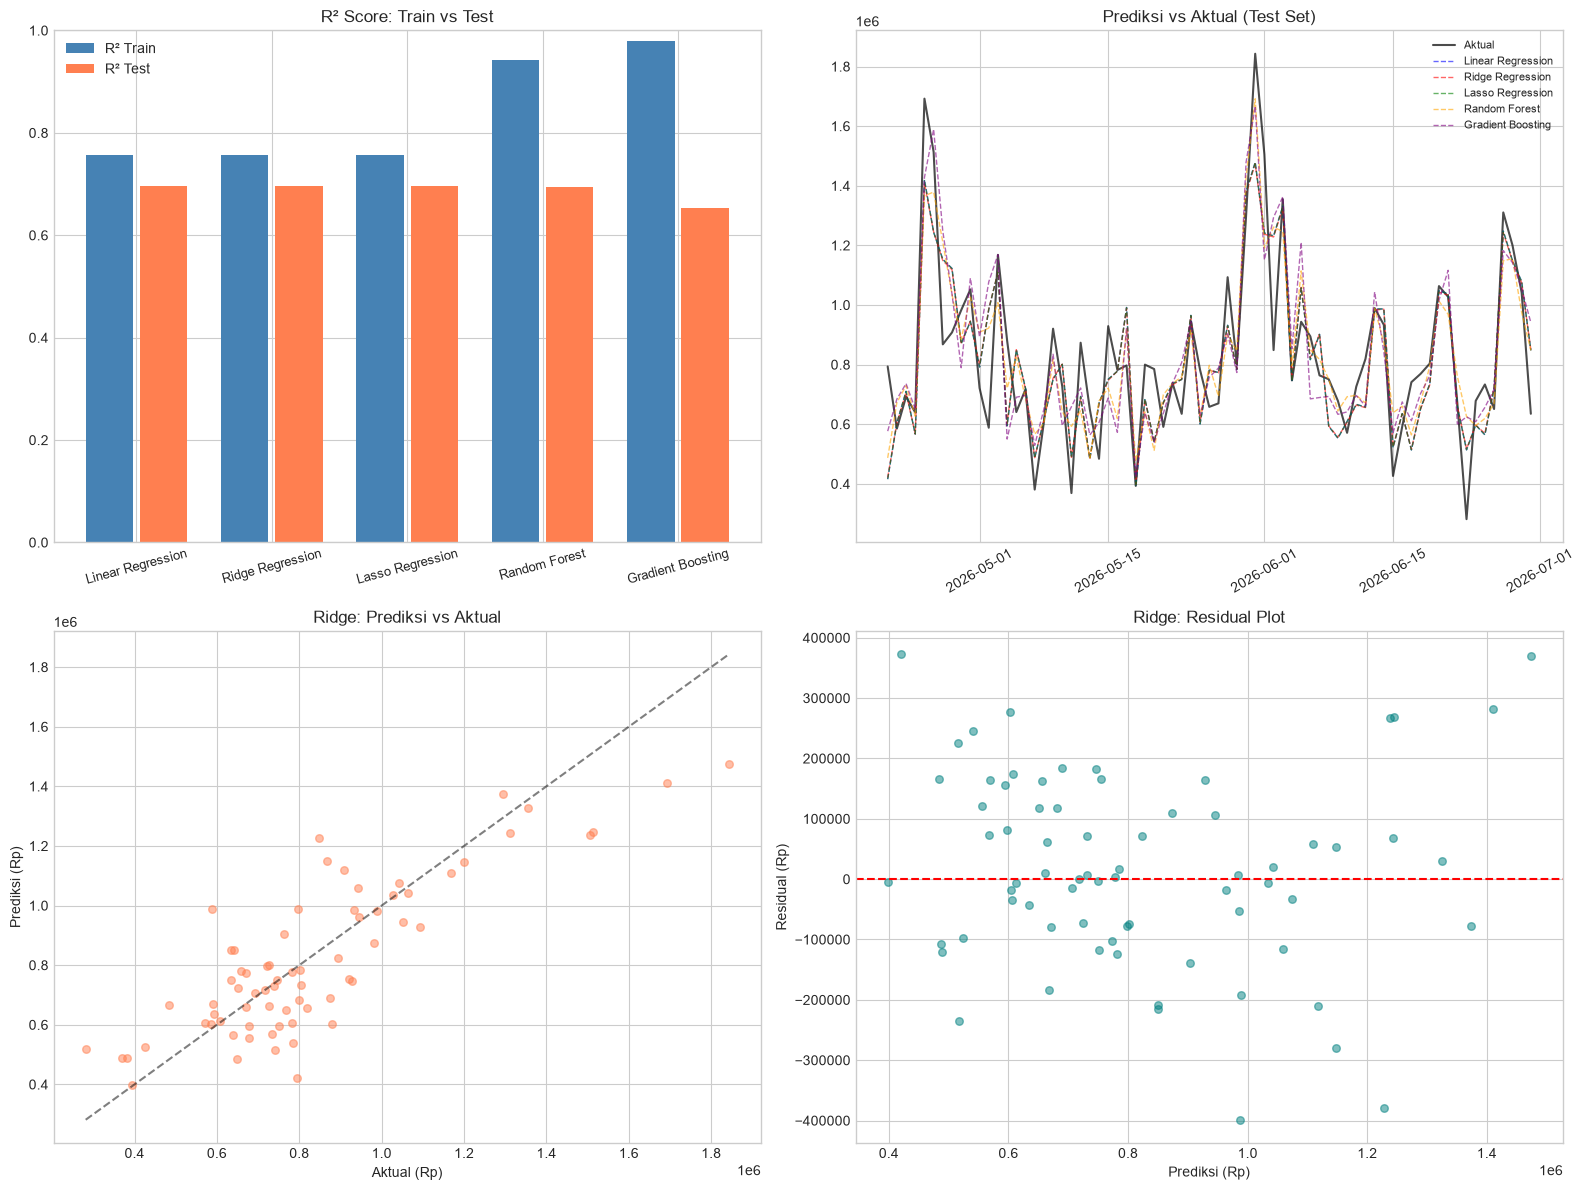

In [6]:
# Cell 6: Visualisasi Perbandingan Model
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Bar Chart
ax = axes[0, 0]
model_names = [r['Model'].split('(')[0].strip() for r in algo_results]
r2_trains = [r['R² Train'] for r in algo_results]
r2_tests = [r['R² Test'] for r in algo_results]
x_pos = np.arange(len(model_names))
ax.bar(x_pos - 0.2, r2_trains, 0.35, label='R² Train', color='steelblue')
ax.bar(x_pos + 0.2, r2_tests, 0.35, label='R² Test', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=15, fontsize=9)
ax.set_title('R² Score: Train vs Test')
ax.legend()
ax.set_ylim(0, 1)

# 2. Prediksi vs Aktual (semua model)
ax = axes[0, 1]
dates_test = daily_clean['date'].values[split_idx:]
ax.plot(dates_test, y_test, 'k-', alpha=0.7, linewidth=1.5, label='Aktual')
colors_line = ['blue', 'red', 'green', 'orange', 'purple']
for (name, pred), clr in zip(predictions.items(), colors_line):
    short = name.split('(')[0].strip()
    ax.plot(dates_test, pred, '--', color=clr, alpha=0.6, linewidth=1, label=short)
ax.set_title('Prediksi vs Aktual (Test Set)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)

# 3. Ridge: Scatter prediksi vs aktual
ax = axes[1, 0]
ridge_pred = predictions['Ridge Regression (α=1.0)']
ax.scatter(y_test, ridge_pred, alpha=0.5, s=30, color='coral')
min_val = min(y_test.min(), ridge_pred.min())
max_val = max(y_test.max(), ridge_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
ax.set_xlabel('Aktual (Rp)')
ax.set_ylabel('Prediksi (Rp)')
ax.set_title('Ridge: Prediksi vs Aktual')

# 4. Ridge: Residual plot
ax = axes[1, 1]
residuals = y_test - ridge_pred
ax.scatter(ridge_pred, residuals, alpha=0.5, s=30, color='teal')
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel('Prediksi (Rp)')
ax.set_ylabel('Residual (Rp)')
ax.set_title('Ridge: Residual Plot')

plt.tight_layout()
plt.show()

HYPERPARAMETER TUNING: Ridge Alpha

Best alpha: 2.0
Best R² Test: 0.6967
   alpha  R² Train  R² Test
  0.0010    0.7571   0.6958
  0.0100    0.7571   0.6958
  0.1000    0.7571   0.6959
  0.5000    0.7571   0.6961
  1.0000    0.7570   0.6964
  2.0000    0.7566   0.6967
  5.0000    0.7542   0.6962
 10.0000    0.7478   0.6927
 50.0000    0.6888   0.6503
100.0000    0.6388   0.6135


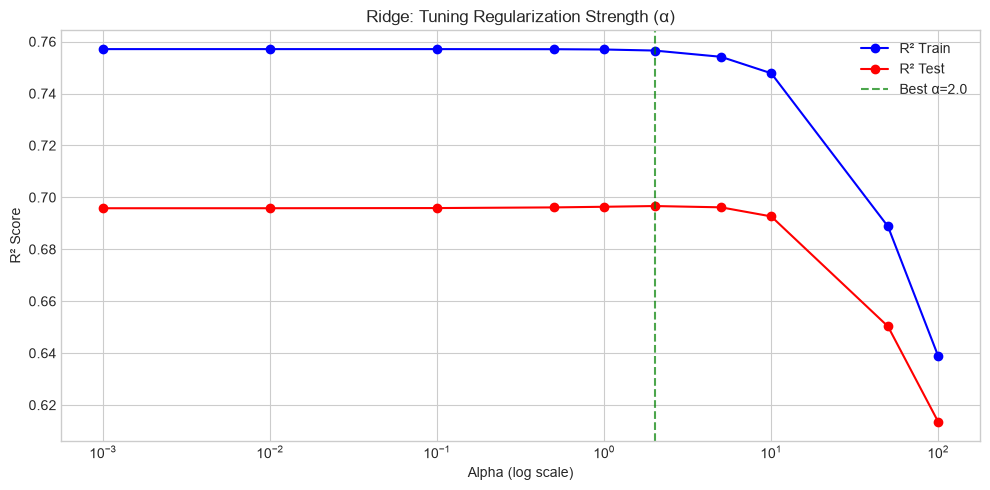

In [7]:
# Cell 7: Hyperparameter Tuning Alpha (Ridge)
print('='*60)
print('HYPERPARAMETER TUNING: Ridge Alpha')
print('='*60)

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]
alpha_results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_s, y_train)
    r2_tr = r2_score(y_train, model.predict(X_train_s))
    r2_te = r2_score(y_test, model.predict(X_test_s))
    alpha_results.append({'alpha': alpha, 'R² Train': r2_tr, 'R² Test': r2_te})

df_alpha = pd.DataFrame(alpha_results)
best = df_alpha.loc[df_alpha['R² Test'].idxmax()]
print(f'\nBest alpha: {best["alpha"]}')
print(f'Best R² Test: {best["R² Test"]:.4f}')
print(df_alpha.to_string(index=False, float_format='{:.4f}'.format))

# Chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(df_alpha['alpha'], df_alpha['R² Train'], 'bo-', label='R² Train')
ax.semilogx(df_alpha['alpha'], df_alpha['R² Test'], 'ro-', label='R² Test')
ax.axvline(x=best['alpha'], color='green', linestyle='--', alpha=0.7, label=f'Best α={best["alpha"]}')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('R² Score')
ax.set_title('Ridge: Tuning Regularization Strength (α)')
ax.legend()
plt.tight_layout()
plt.show()

CROSS-VALIDATION: TimeSeriesSplit (5 Fold)

TimeSeriesSplit menjaga urutan waktu, tidak acak seperti KFold biasa.
Ref: Bergmeir & Benítez (2012), Information Sciences

  Fold 1: Train=62, Test=58 → R²=0.5969, MAE=Rp 160,355
  Fold 2: Train=120, Test=58 → R²=0.6980, MAE=Rp 148,019
  Fold 3: Train=178, Test=58 → R²=0.7299, MAE=Rp 159,827
  Fold 4: Train=236, Test=58 → R²=0.7971, MAE=Rp 153,574
  Fold 5: Train=294, Test=58 → R²=0.7215, MAE=Rp 114,853

  Rata-rata R²: 0.7087 (±0.0726)
  Rata-rata MAE: Rp 147,326


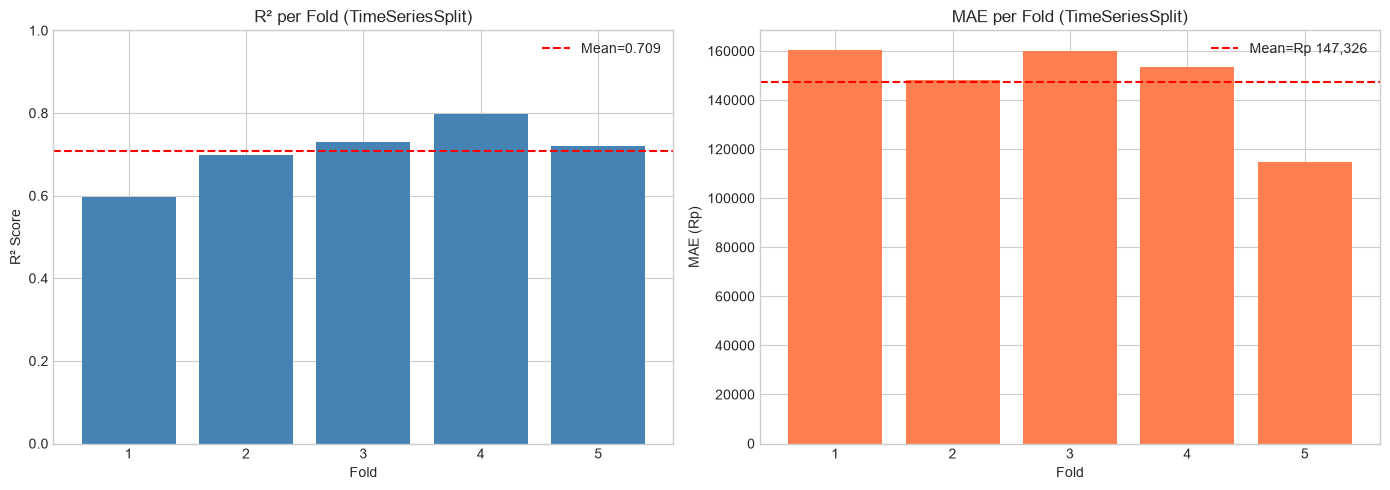

In [8]:
# Cell 8: TimeSeriesSplit Cross-Validation
print('='*70)
print('CROSS-VALIDATION: TimeSeriesSplit (5 Fold)')
print('='*70)
print()
print('TimeSeriesSplit menjaga urutan waktu, tidak acak seperti KFold biasa.')
print('Ref: Bergmeir & Benítez (2012), Information Sciences')
print()

X_all = daily_clean[features_v2].values
y_all = daily_clean['revenue'].values

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all), 1):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]
    
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    
    best_alpha_val = best['alpha']
    model = Ridge(alpha=best_alpha_val)
    model.fit(X_tr_s, y_tr)
    
    pred = model.predict(X_te_s)
    r2 = r2_score(y_te, pred)
    mae = mean_absolute_error(y_te, pred)
    
    cv_scores.append({'Fold': fold, 'Train Size': len(train_idx), 'Test Size': len(test_idx),
                      'R²': r2, 'MAE': mae})
    print(f'  Fold {fold}: Train={len(train_idx)}, Test={len(test_idx)} → R²={r2:.4f}, MAE=Rp {mae:,.0f}')

df_cv = pd.DataFrame(cv_scores)
print(f'\n  Rata-rata R²: {df_cv["R²"].mean():.4f} (±{df_cv["R²"].std():.4f})')
print(f'  Rata-rata MAE: Rp {df_cv["MAE"].mean():,.0f}')

# Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(df_cv['Fold'], df_cv['R²'], color='steelblue')
ax1.axhline(y=df_cv['R²'].mean(), color='red', linestyle='--', label=f'Mean={df_cv["R²"].mean():.3f}')
ax1.set_xlabel('Fold')
ax1.set_ylabel('R² Score')
ax1.set_title('R² per Fold (TimeSeriesSplit)')
ax1.legend()
ax1.set_ylim(0, 1)

ax2.bar(df_cv['Fold'], df_cv['MAE'], color='coral')
ax2.axhline(y=df_cv['MAE'].mean(), color='red', linestyle='--', label=f'Mean=Rp {df_cv["MAE"].mean():,.0f}')
ax2.set_xlabel('Fold')
ax2.set_ylabel('MAE (Rp)')
ax2.set_title('MAE per Fold (TimeSeriesSplit)')
ax2.legend()

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE (Ridge Coefficients)

Feature Importance (by |coefficient| on scaled data):
        rolling_3d_avg:    396,084.1 ↑
                 lag_1:   -164,625.4 ↓
            is_weekend:     88,935.6 ↑
        rolling_7d_avg:    -64,365.8 ↓
             is_payday:     47,843.9 ↑
           day_of_week:     39,491.4 ↑
            is_ramadan:     37,377.0 ↑
               day_cos:    -31,997.5 ↓
               day_sin:     28,162.4 ↑
                 month:      8,580.8 ↑
                 lag_7:      5,085.6 ↑
            is_holiday:      2,547.8 ↑

Intercept: Rp 832,579


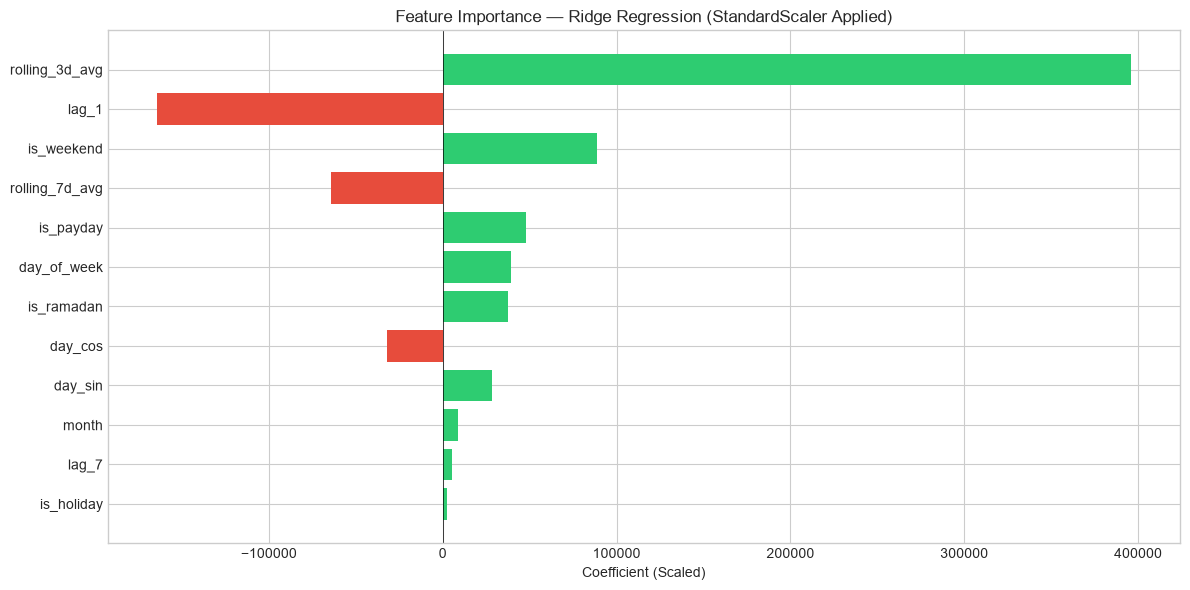

In [9]:
# Cell 9: Feature Importance
print('='*60)
print('FEATURE IMPORTANCE (Ridge Coefficients)')
print('='*60)

# Retrain final model with best alpha
final_scaler = StandardScaler()
X_train_final = final_scaler.fit_transform(X_train)
X_test_final = final_scaler.transform(X_test)

final_model = Ridge(alpha=best['alpha'])
final_model.fit(X_train_final, y_train)

importance = pd.DataFrame({
    'Feature': features_v2,
    'Coefficient': final_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('\nFeature Importance (by |coefficient| on scaled data):')
for _, row in importance.iterrows():
    direction = '↑' if row['Coefficient'] > 0 else '↓'
    print(f'  {row["Feature"]:>20}: {row["Coefficient"]:>12,.1f} {direction}')

print(f'\nIntercept: Rp {final_model.intercept_:,.0f}')

# Chart
fig, ax = plt.subplots(figsize=(12, 6))
colors_fi = ['#2ecc71' if c > 0 else '#e74c3c' for c in importance['Coefficient']]
ax.barh(importance['Feature'], importance['Coefficient'], color=colors_fi)
ax.set_xlabel('Coefficient (Scaled)')
ax.set_title('Feature Importance — Ridge Regression (StandardScaler Applied)')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Kesimpulan
final_r2 = r2_score(y_test, final_model.predict(X_test_final))
final_mae = mean_absolute_error(y_test, final_model.predict(X_test_final))
final_mape = np.mean(np.abs((y_test - final_model.predict(X_test_final)) / y_test)) * 100

print('='*70)
print('KESIMPULAN MODEL COMPARISON v2')
print('='*70)
print()
print('IMPROVEMENT vs v1:')
print(f'  Data: 91 hari → 365 hari')
print(f'  Fitur: 4 → 12 fitur')
print(f'  StandardScaler: Tidak → Ya')
print(f'  Cross-Validation: Simple split → TimeSeriesSplit')
print()
print('HASIL FINAL:')
print(f'  Algoritma: Ridge Regression (α={best["alpha"]})')
print(f'  R² Test: {final_r2:.4f}')
print(f'  MAE: Rp {final_mae:,.0f}')
print(f'  MAPE: {final_mape:.1f}%')
print(f'  CV Mean R²: {df_cv["R²"].mean():.4f} (±{df_cv["R²"].std():.4f})')
print()
print('ALASAN PEMILIHAN RIDGE:')
print('  1. Stabil (gap train-test kecil)')
print('  2. Tidak overfitting (berbeda dengan Random Forest)')
print('  3. Interpretatif (koefisien bisa dibaca langsung)')
print('  4. Cepat (cocok untuk sistem real-time POS)')
print('  5. Regularisasi mencegah koefisien terlalu ekstrem')

KESIMPULAN MODEL COMPARISON v2

IMPROVEMENT vs v1:
  Data: 91 hari → 365 hari
  Fitur: 4 → 12 fitur
  StandardScaler: Tidak → Ya
  Cross-Validation: Simple split → TimeSeriesSplit

HASIL FINAL:
  Algoritma: Ridge Regression (α=2.0)
  R² Test: 0.6967
  MAE: Rp 125,205
  MAPE: 16.5%
  CV Mean R²: 0.7087 (±0.0726)

ALASAN PEMILIHAN RIDGE:
  1. Stabil (gap train-test kecil)
  2. Tidak overfitting (berbeda dengan Random Forest)
  3. Interpretatif (koefisien bisa dibaca langsung)
  4. Cepat (cocok untuk sistem real-time POS)
  5. Regularisasi mencegah koefisien terlalu ekstrem
